# Macro Regimes and Asset Performance

## tl;dr

- The transparent rule classifies **1,111 trading days** from **2021-07-07 to 2025-12-30** using the prior trading day's VIX and 63-day change in the US 10-year yield.
- During **Tightening**, GLD produced a 14.0% annualised price return, while SPY returned -6.4% and IEF -1.0%.
- During **Elevated risk**, GLD led at 31.5%; SPY's volatility rose to 22.3%.
- **Stress has only 62 observations.** SPY's positive conditional mean and 36.4% volatility are treated as a short-sample mean-reversion result, not evidence that equities are defensive.

All figures are descriptive associations, not forecasts or investment advice.

## Context & Methods

### Regime rules

Rules are evaluated in priority order using information available at the **previous trading close**:

| Regime | Exact rule |
|---|---|
| Stress | prior VIX ≥ 30 |
| Elevated risk | 20 ≤ prior VIX < 30 |
| Tightening | prior VIX < 20 and prior 63-trading-day DGS10 change ≥ +0.50 percentage points |
| Calm / easing | prior VIX < 20 and prior 63-trading-day DGS10 change < +0.50 percentage points |
| Unclassified | any required signal is missing or the 63-day warm-up is incomplete |

Boundary handling is explicit: VIX = 30 is Stress, VIX = 20 is Elevated risk, and a yield change of exactly +0.50 pp is Tightening. Stress and Elevated risk take precedence over the yield rule. Thresholds are heuristic and were **not optimised against asset returns**.

### Key assumptions

- Returns use the stored Yahoo Finance `close_price` series. The legacy extraction did not preserve yfinance's `auto_adjust` setting, so adjustment status is not claimed.
- Annualised return = mean daily return × 252; annualised volatility = sample daily standard deviation × √252.
- Sharpe ratio uses a 0% risk-free rate to keep the conditional comparison reproducible.
- Maximum drawdown is the worst peak-to-trough loss within any contiguous episode of that regime.
- FRED values are backward as-of joined to an asset trading date with a maximum seven-calendar-day tolerance.
- Conditional daily observations are not independent; results are descriptive and sensitive to thresholds and the 2021–2025 sample.

## Data

Model inputs are SPY, IEF, and GLD prices from Yahoo Finance plus FRED VIXCLS and DGS10. Bank of England and ONS snapshots are retained as supplementary sources but deliberately excluded from the US-asset regime classifier. See `data/README.md` and `data/source_manifest.csv` for lineage, coverage, and freshness details.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.build_analysis import run_analysis

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
PROJECT_ROOT

WindowsPath('C:/Users/wldbs/OneDrive/바탕화면/Works/project3')

In [2]:
# Rebuild every processed table and chart from the raw snapshots.
results = run_analysis(PROJECT_ROOT)
print(f"Analysis window: {results['qa_dict']['analysis_start']} to {results['qa_dict']['analysis_end']}")
print(f"Classified trading days: {results['qa_dict']['classified_days']:,}")

Analysis window: 2021-07-07 to 2025-12-30
Classified trading days: 1,111


## Results

### Data-quality checks

In [3]:
results['qa']

,check,value
0,asset_rows_raw,15846
1,asset_duplicate_keys,0
2,asset_null_dates,0
3,asset_null_prices,0
4,vix_rows_raw,1305
5,vix_duplicate_dates,0
6,vix_null_values,20
7,dgs10_rows_raw,1305
8,dgs10_duplicate_dates,0
9,dgs10_null_values,55


### Regime classification and boundaries

In [4]:
classification = results['summary'].copy()
classification['share_of_classified_days'] = classification['share_of_classified_days'].map(lambda x: f'{x:.1%}')
classification

,regime,trading_days,first_date,last_date,median_signal_vix,median_signal_dgs10,median_signal_dgs10_change_63d_pp,share_of_classified_days
0,Calm / easing,619,2021-07-07,2025-12-30,16.1500,4.1000,-0.0700,55.7%
1,Tightening,108,2022-03-29,2025-01-23,16.2450,4.5100,0.6600,9.7%
2,Elevated risk,322,2021-07-20,2025-11-25,23.1300,3.4750,0.1750,29.0%
3,Stress,62,2021-12-02,2025-04-23,31.8050,3.2950,0.6400,5.6%


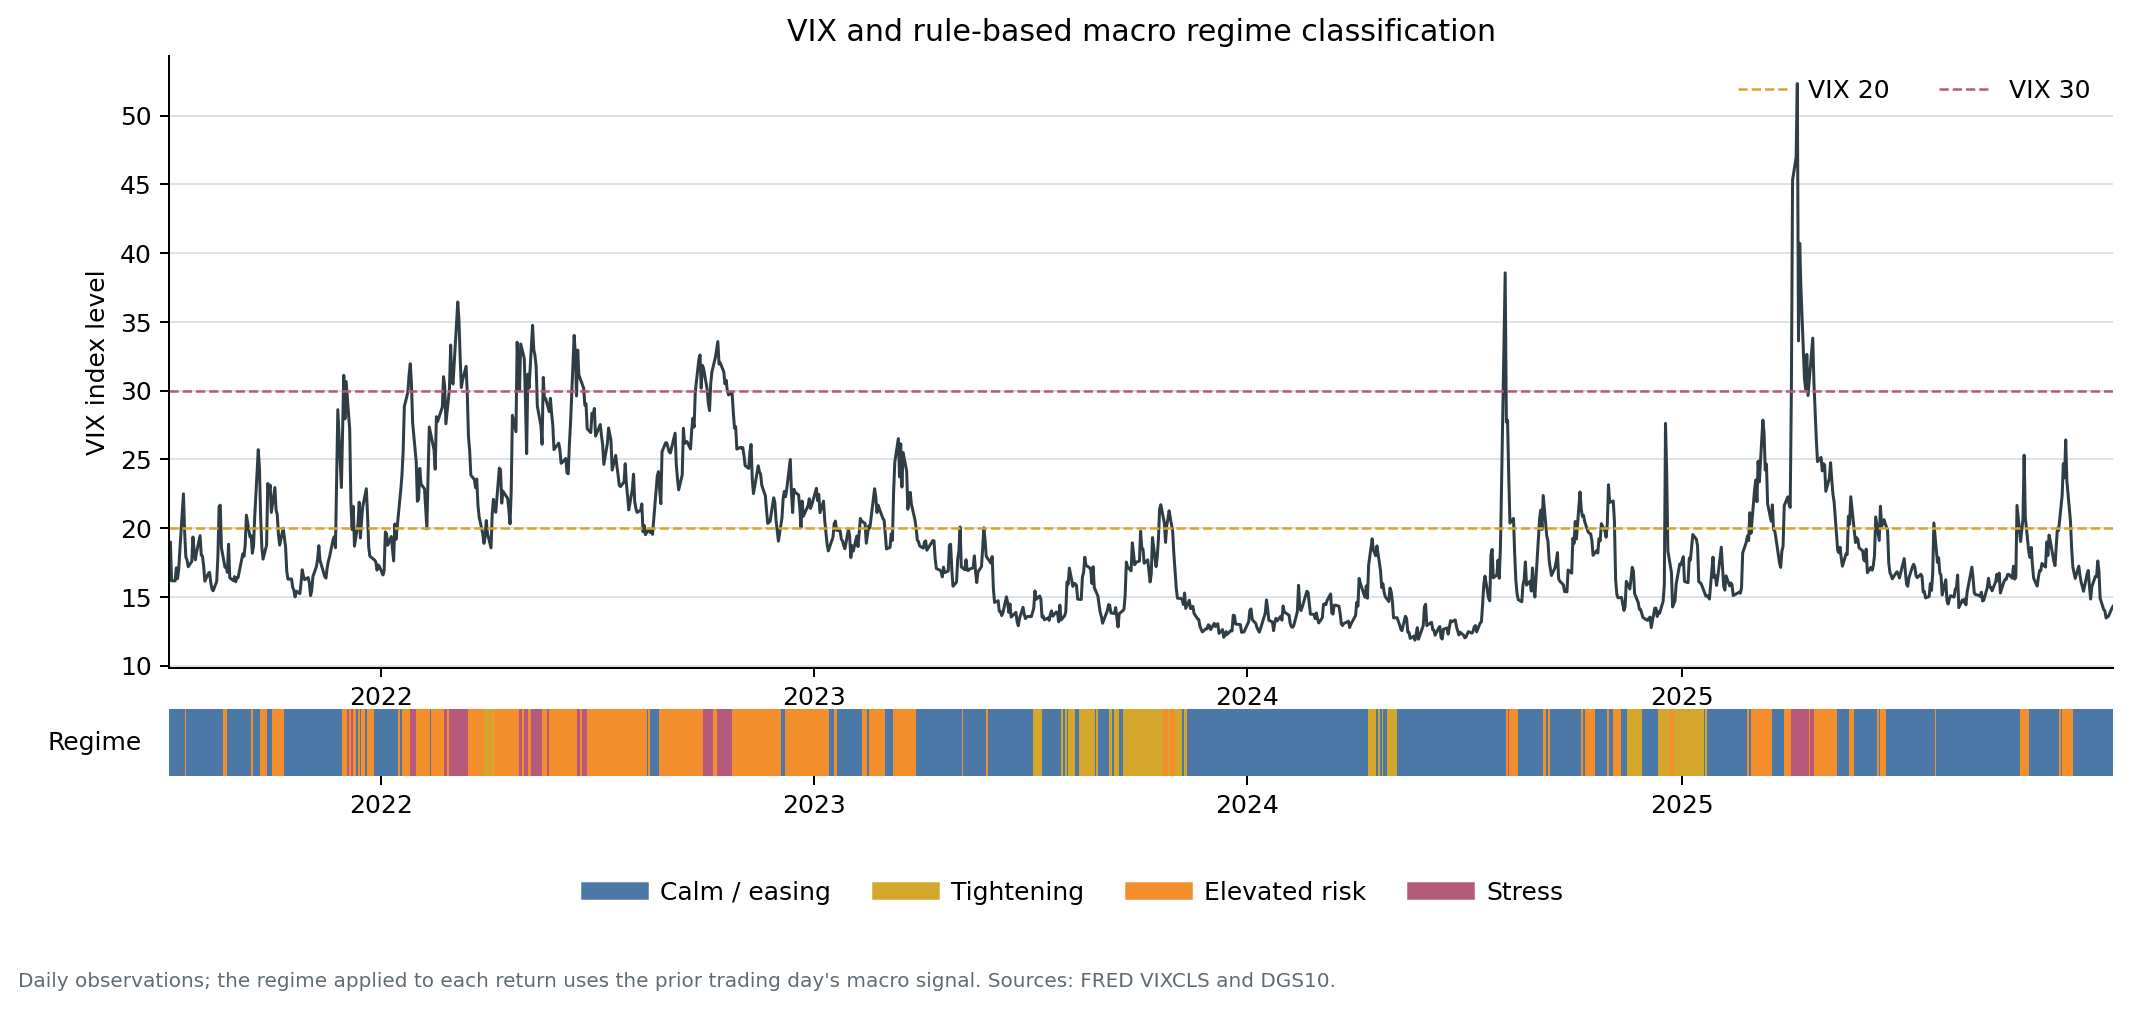

In [5]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/macro_regime_timeline.png'), width=1000))

### Return and risk metrics

In [6]:
metric_view = results['metrics'][['regime', 'ticker', 'observations', 'annualized_return', 'annualized_volatility', 'max_drawdown', 'sharpe_ratio_rf0']].copy()
for column in ['annualized_return', 'annualized_volatility', 'max_drawdown']:
    metric_view[column] = metric_view[column].map(lambda x: f'{x:.1%}')
metric_view['sharpe_ratio_rf0'] = metric_view['sharpe_ratio_rf0'].map(lambda x: f'{x:.2f}')
metric_view

,regime,ticker,observations,annualized_return,annualized_volatility,max_drawdown,sharpe_ratio_rf0
0,Calm / easing,GLD,619,20.0%,14.9%,-10.1%,1.35
1,Calm / easing,IEF,619,0.5%,6.8%,-4.4%,0.07
2,Calm / easing,SPY,619,11.3%,11.4%,-5.7%,0.99
3,Tightening,GLD,108,14.0%,14.3%,-5.9%,0.98
4,Tightening,IEF,108,-1.0%,8.2%,-4.1%,-0.12
5,Tightening,SPY,108,-6.4%,13.8%,-5.0%,-0.46
6,Elevated risk,GLD,322,31.5%,16.2%,-7.7%,1.95
7,Elevated risk,IEF,322,-1.1%,9.3%,-6.9%,-0.11
8,Elevated risk,SPY,322,13.1%,22.3%,-13.3%,0.59
9,Stress,GLD,62,-22.1%,22.9%,-6.6%,-0.97


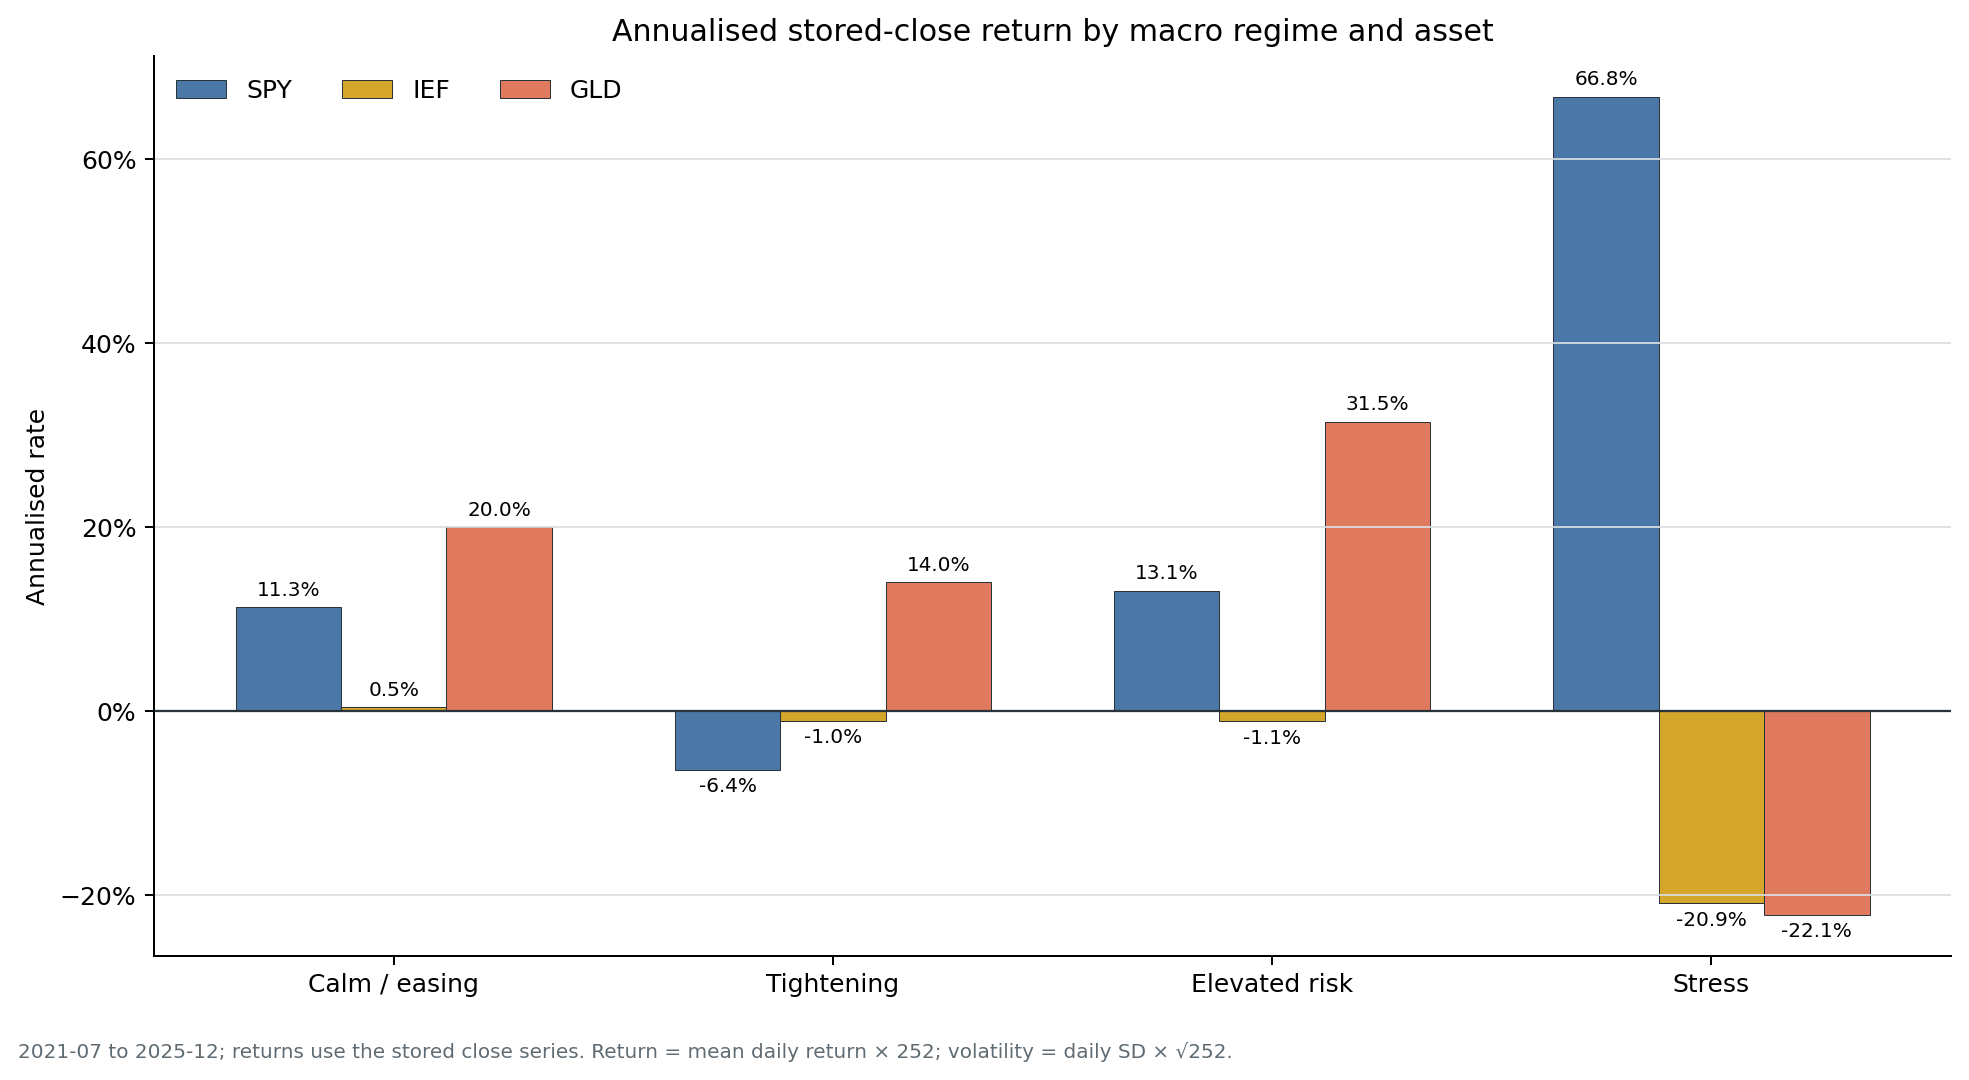

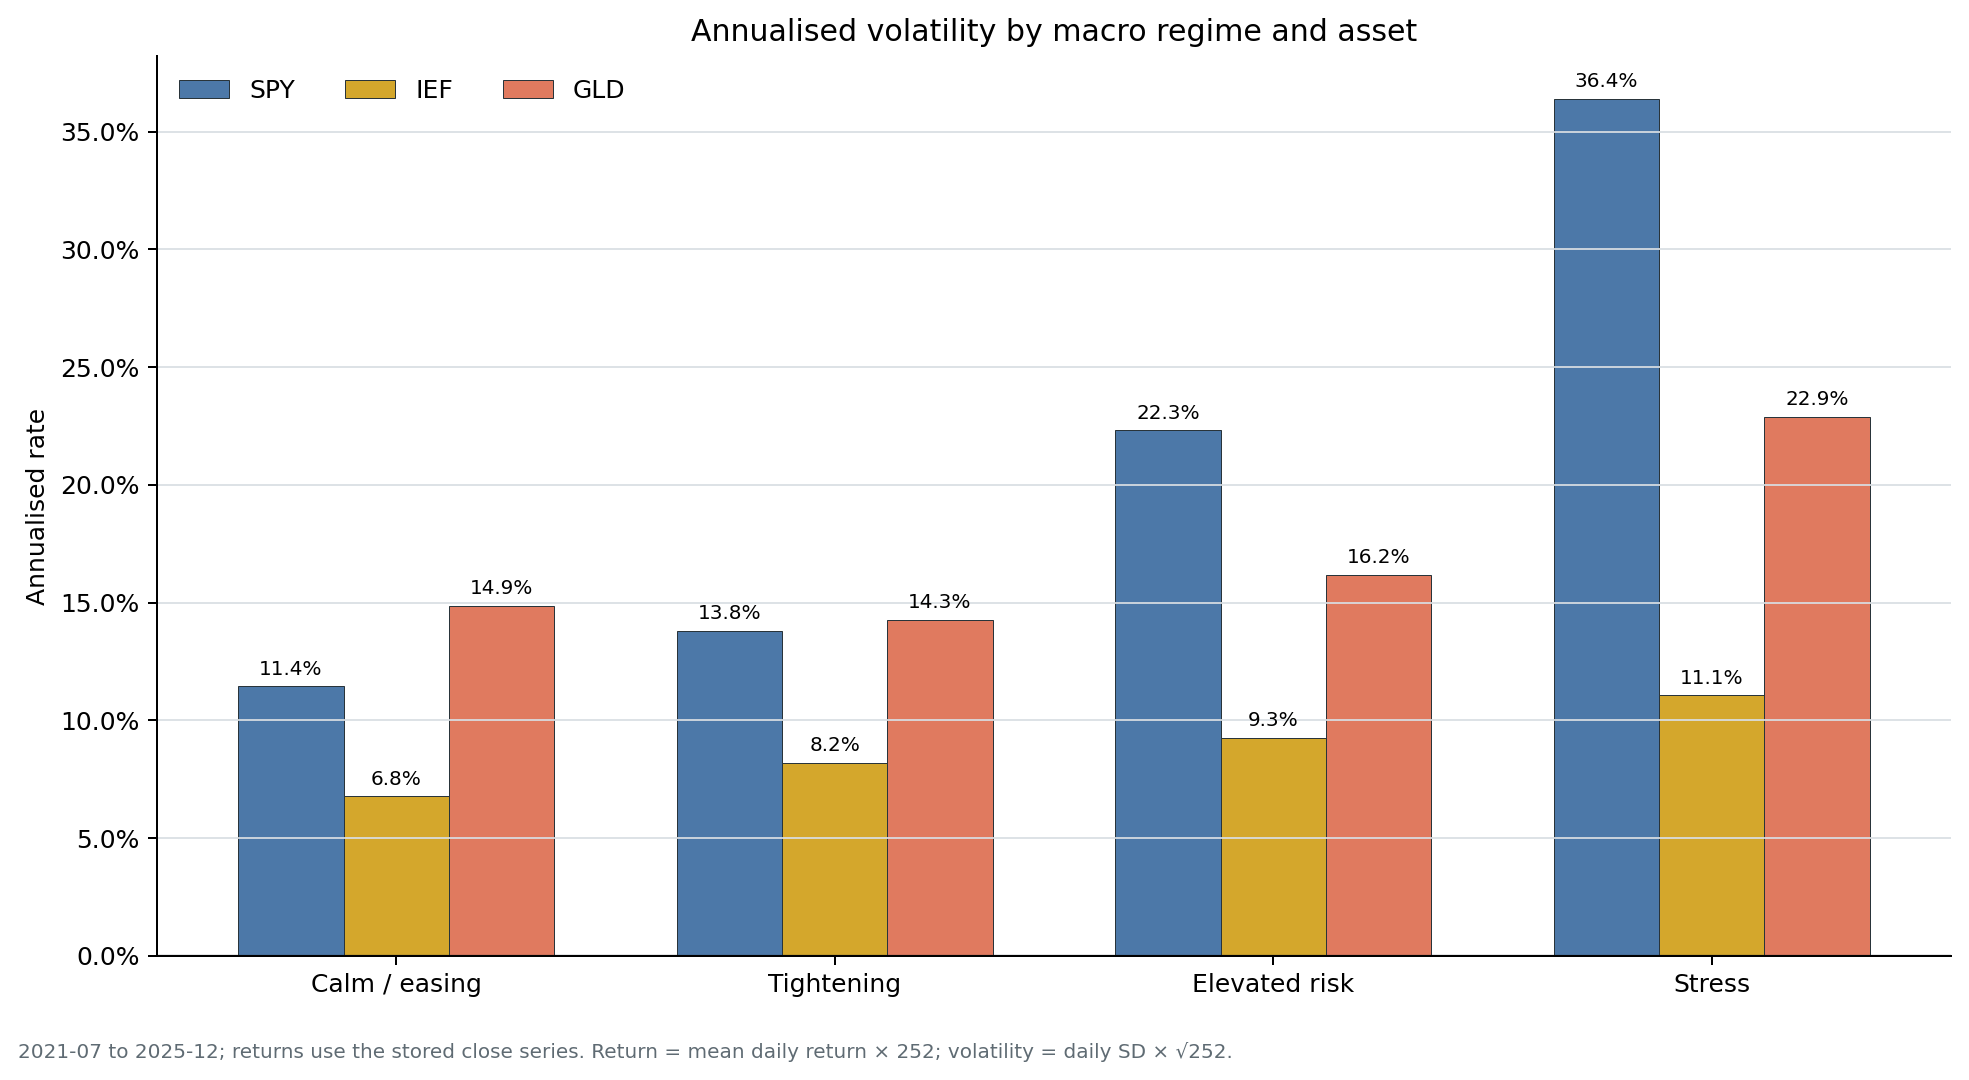

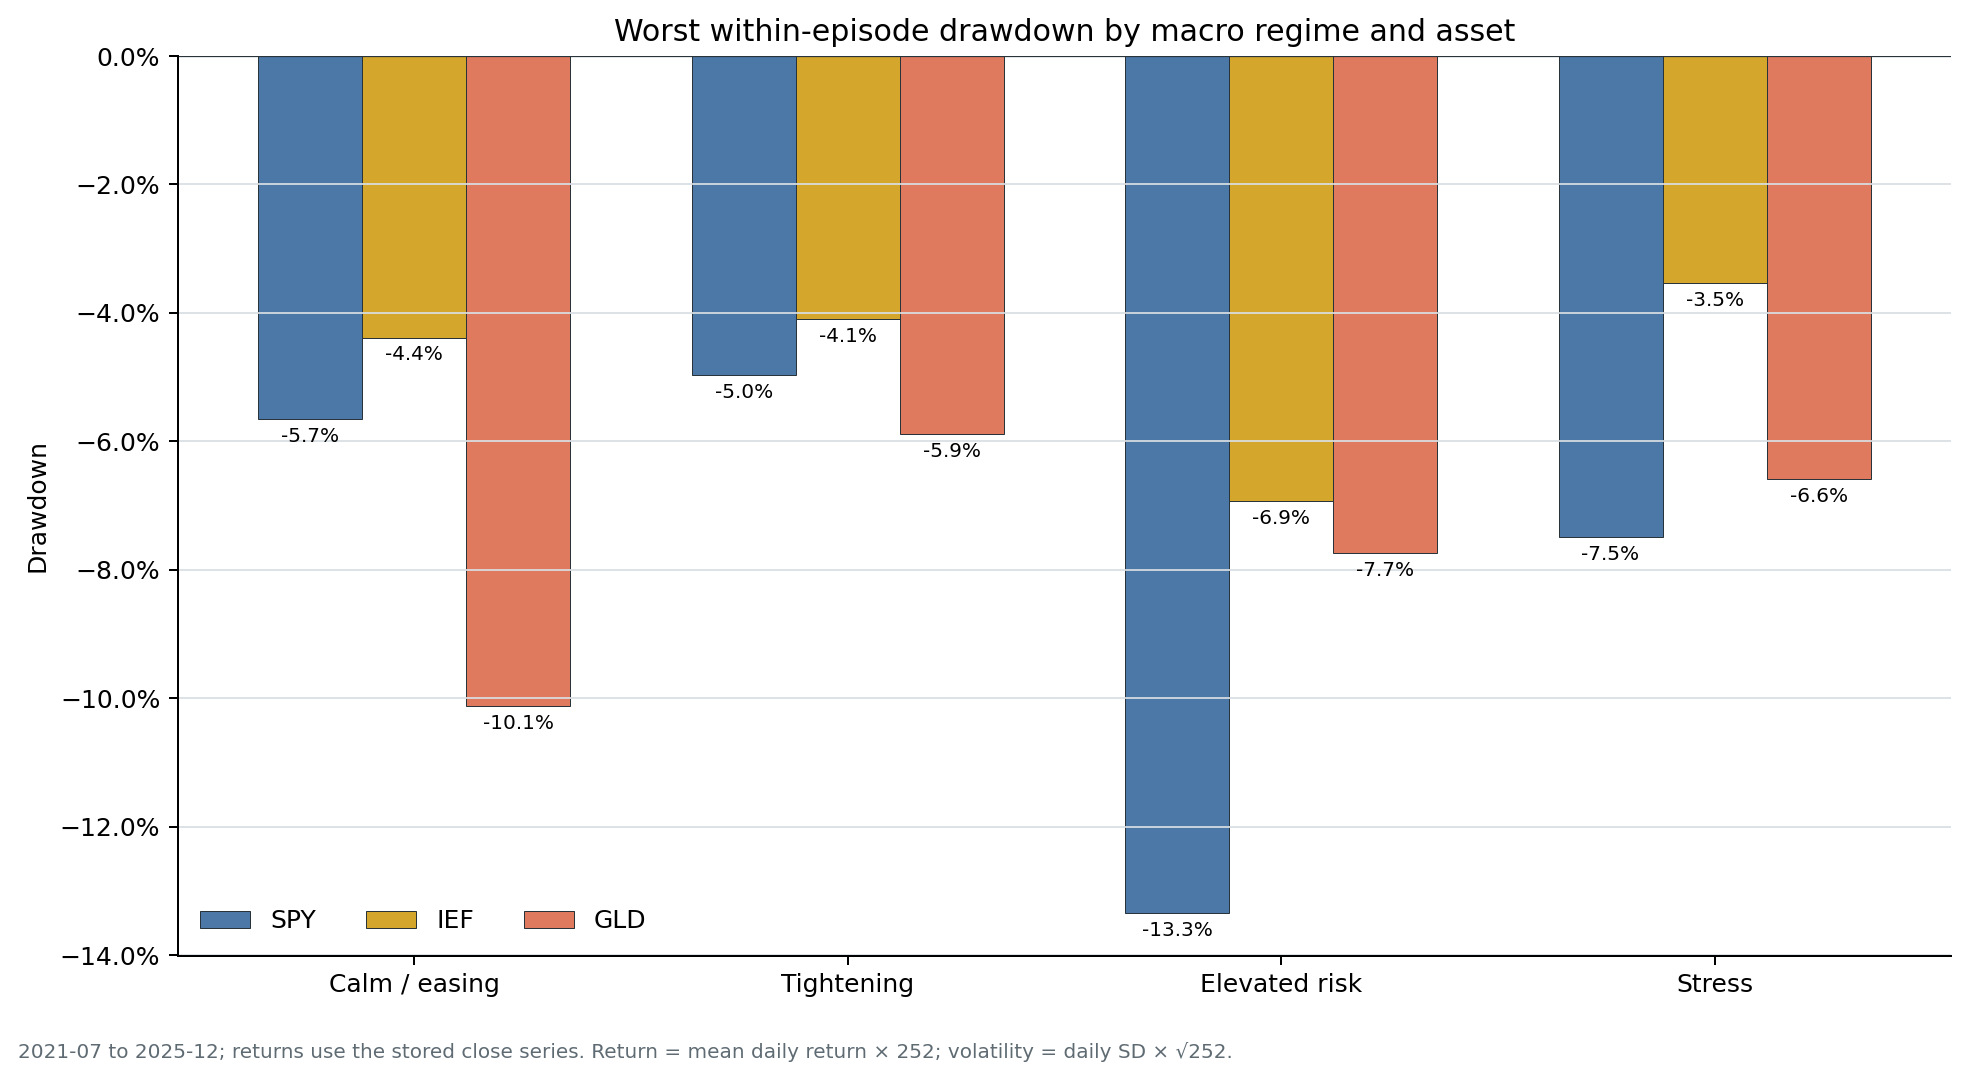

In [7]:
for filename in ['regime_annualized_returns.png', 'regime_annualized_volatility.png', 'regime_max_drawdown.png']:
    display(Image(filename=str(PROJECT_ROOT / 'outputs/figures' / filename), width=950))

### Conditional correlations

In [8]:
correlation_view = results['correlations'].copy()
correlation_view['correlation'] = correlation_view['correlation'].round(2)
correlation_view

,regime,asset_1,asset_2,observations,correlation
0,Calm / easing,SPY,IEF,619,0.0400
1,Calm / easing,SPY,GLD,619,0.1500
2,Calm / easing,IEF,GLD,619,0.3200
3,Tightening,SPY,IEF,108,0.4200
4,Tightening,SPY,GLD,108,0.1900
5,Tightening,IEF,GLD,108,0.1900
6,Elevated risk,SPY,IEF,322,0.0300
7,Elevated risk,SPY,GLD,322,0.0700
8,Elevated risk,IEF,GLD,322,0.4100
9,Stress,SPY,IEF,62,0.0300


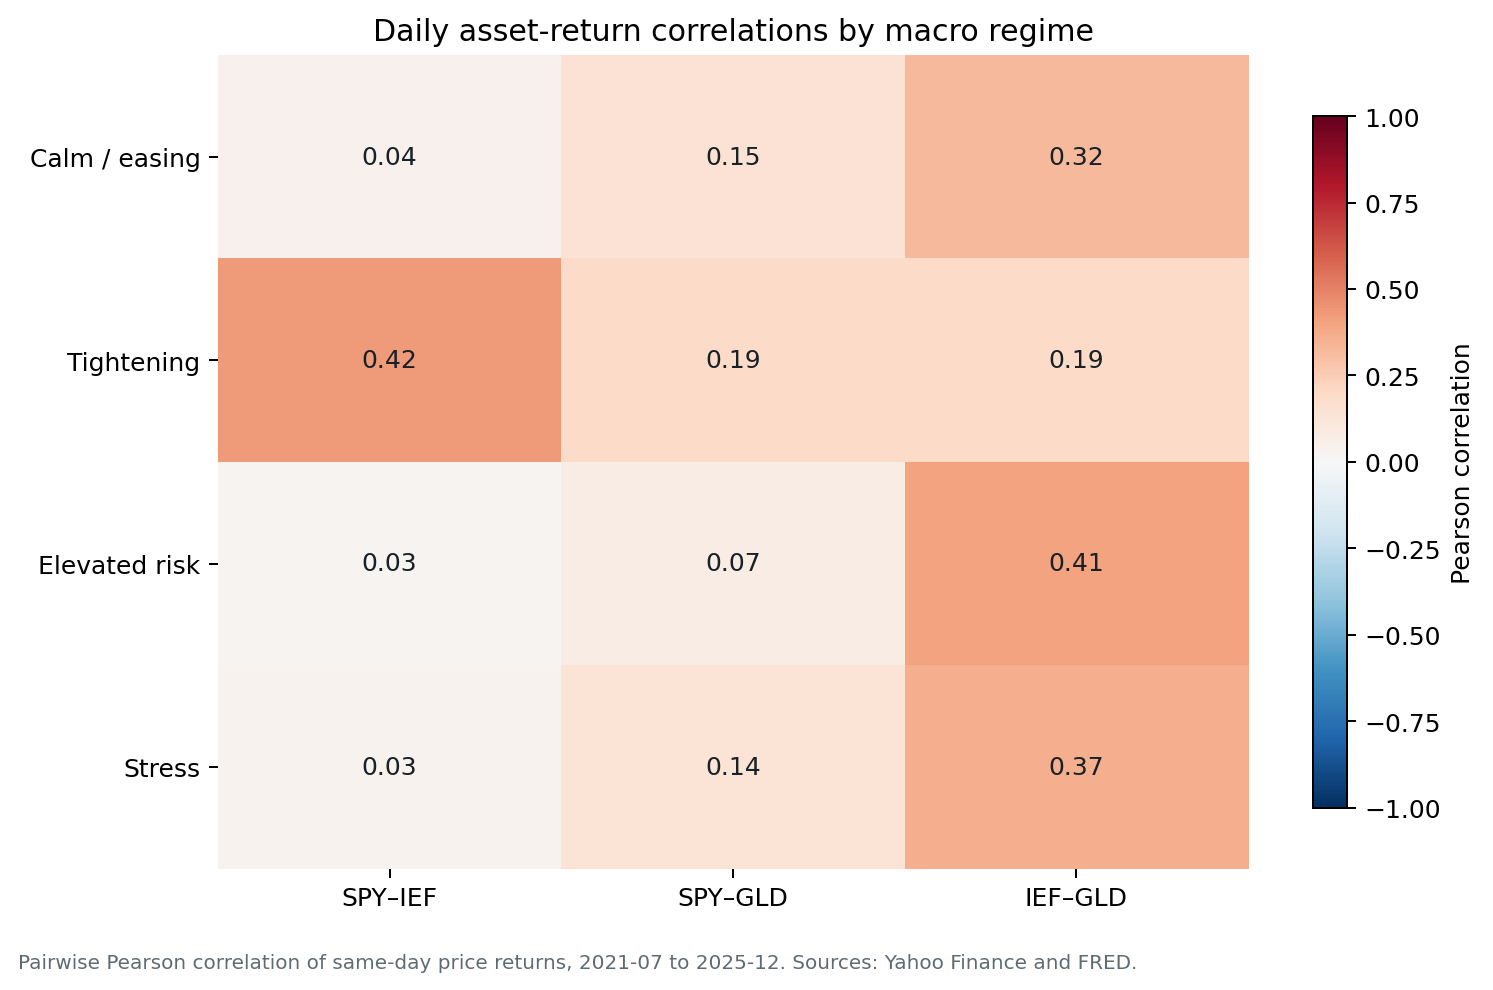

In [9]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/regime_correlations.png'), width=850))

## Takeaways

1. **Gold was the clearest relative winner in tightening and elevated-risk observations.** Its annualised price return was 14.0% in Tightening and 31.5% in Elevated risk.
2. **The bond proxy was not consistently defensive in this sample.** IEF returned -1.0% in Tightening and -20.9% in Stress. That result is specific to a period dominated by inflation and rate shocks.
3. **Stress estimates are fragile.** Only 62 days qualify, and the positive SPY mean combines with 36.4% annualised volatility. This is better read as short-horizon rebound behaviour than a stable regime premium.
4. **Diversification varied by state.** SPY–IEF correlation was highest in Tightening, while IEF–GLD correlation remained positive across all regimes in this snapshot.

The next analytical step would be a robustness appendix covering alternative VIX/yield thresholds, monthly sampling, total-return data, and confidence intervals. Those tests are not claimed here.